# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

## 1. EDA


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
print("Kształt zbioru danych:", df.shape)
display(df.head())


Kształt zbioru danych: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


/var/folders/s5/fc27vd4n1v7_7snyvwrbdsn40000gn/T/ipykernel_88069/3766658533.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis')


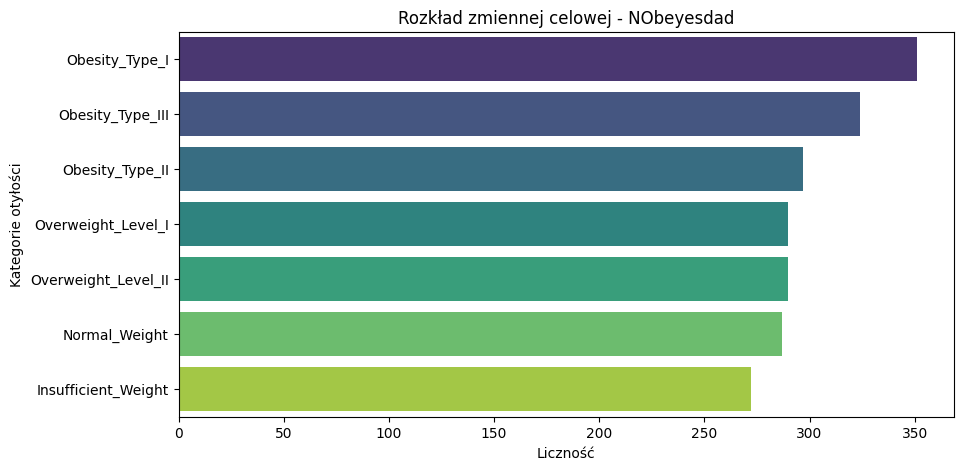

In [86]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index, palette='viridis')
plt.title('Rozkład zmiennej celowej - NObeyesdad')
plt.xlabel('Liczność')
plt.ylabel('Kategorie otyłości')
plt.show()

/var/folders/s5/fc27vd4n1v7_7snyvwrbdsn40000gn/T/ipykernel_88069/445129014.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_mapped.select_dtypes(include=['object']).columns


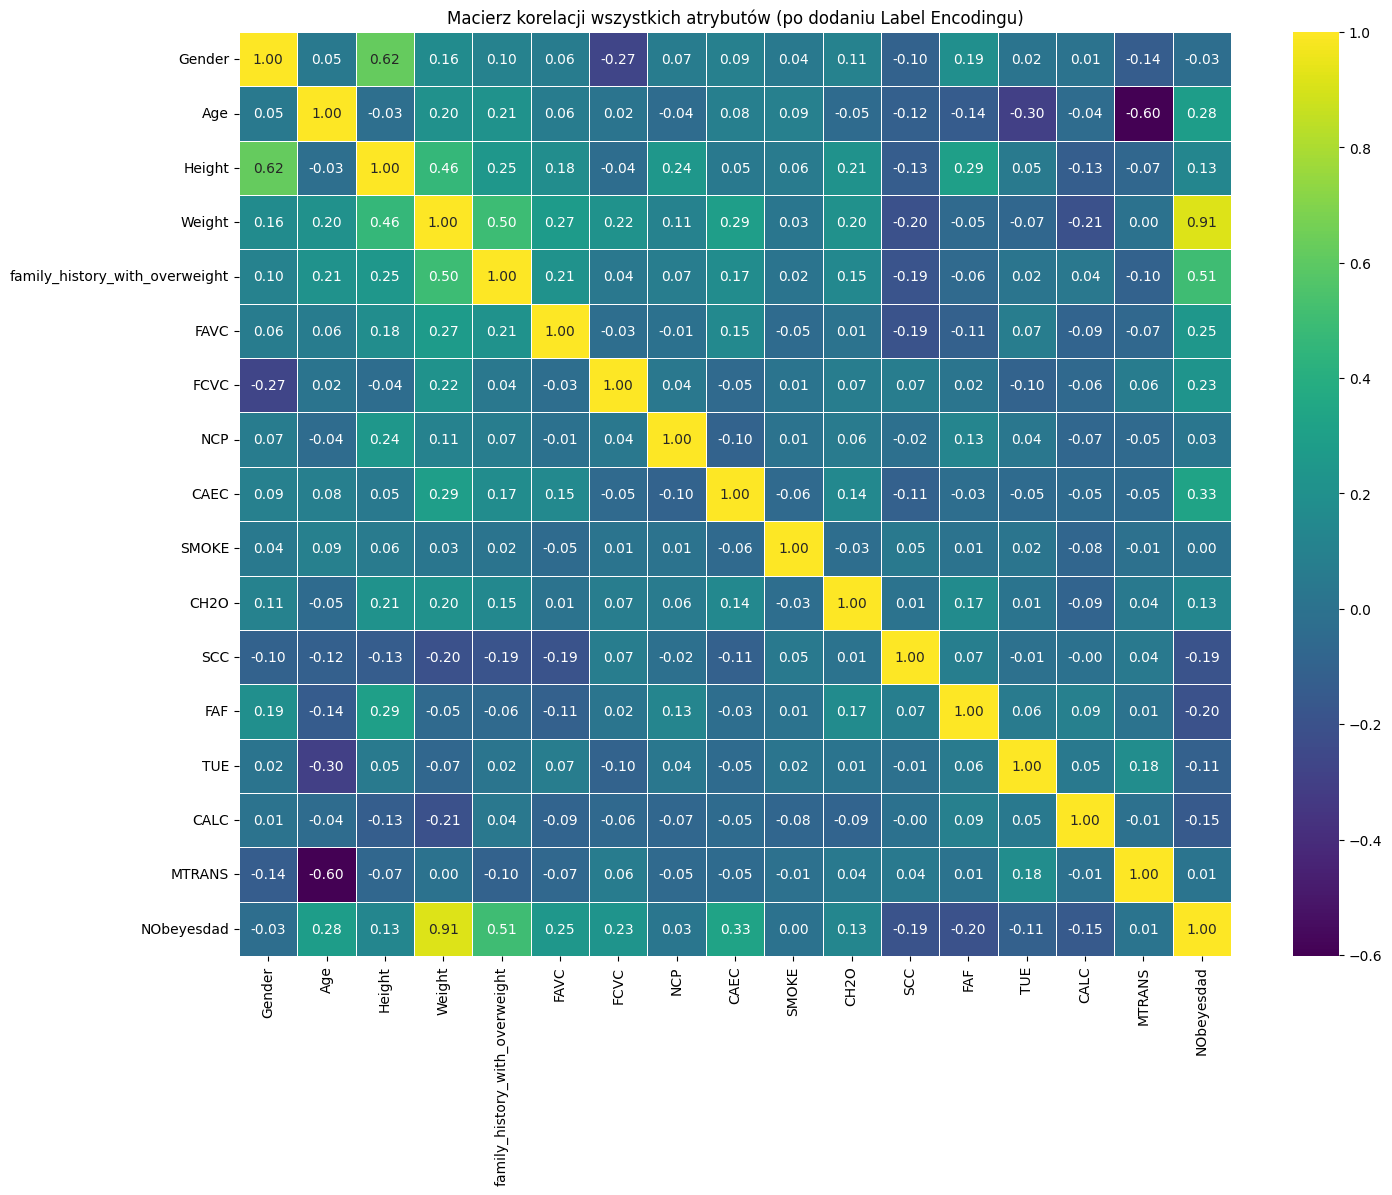

In [87]:
# mozemy zrobic taki mapping poniewaz rzeczywiscie jest to skala nie sa to osobne przypadki
# jak gdyby na przyklad bylyby to ptaki ssaki ryby bo wtedy nie byloby to uporzadkowane
obesity_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df['NObeyesdad'] = df['NObeyesdad'].map(obesity_mapping)

df_mapped = df.copy()

# label encoding zeby bylo dobrze widac na macierzy
categorical_cols = df_mapped.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_mapped[col] = df_mapped[col].astype('category').cat.codes

plt.figure(figsize=(16, 12))
correlation_matrix = df_mapped.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji wszystkich atrybutów (po dodaniu Label Encodingu)')
plt.show()

In [88]:
from sklearn.model_selection import train_test_split

# Wyrzucamy mało istotne cechy zidentyfikowane na macierzy uprzednio
df = df.drop(columns=['SMOKE', 'Gender', 'MTRANS', 'NCP'], errors='ignore')

duplicates_count = df.duplicated().sum()
print(f"Liczba duplikatów przed czyszczeniem: {duplicates_count}")
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Usunięto duplikaty. Nowy kształt danych: {df.shape}")

# Rzutujemy target na przedział 0-1 (Osoby z >=4 wg mapowania to osoby otyłe: Type I, II i III)
y = (df['NObeyesdad'] >= 4).astype(int)

X = df.drop(columns=['NObeyesdad'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, axis=1, fill_value=0)

print("\n--- PODZIAŁ DANYCH ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Liczba duplikatów przed czyszczeniem: 24
Usunięto duplikaty. Nowy kształt danych: (2087, 13)

--- PODZIAŁ DANYCH ---
X_train shape: (1669, 16)
X_test shape: (418, 16)
y_train shape: (1669,)
y_test shape: (418,)


## 2. Modele

### Baseline

In [89]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score
import time

start_time = time.time()

baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train, y_train)

# mierzymy czas
pred_start_time = time.time()
y_pred_baseline = baseline_model.predict(X_test)
pred_time_baseline = time.time() - pred_start_time
total_time = time.time() - start_time

# metryka
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f"F1-Score (weighted): {f1_baseline*100:.2f}%")
print(f"Czas predykcji na zbiorze testowym: {pred_time_baseline*1000:.2f} ms")
print(f"Całkowity czas (trening + predykcja): {total_time*1000:.2f} ms\n")

F1-Score (weighted): 37.12%
Czas predykcji na zbiorze testowym: 0.27 ms
Całkowity czas (trening + predykcja): 0.78 ms



In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import time

start_time = time.time()
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# mierzymy czas
pred_start_time = time.time()
y_pred_tree = tree_model.predict(X_test)
pred_time_tree = time.time() - pred_start_time
total_time = time.time() - start_time

# metryka
f1_tree = f1_score(y_test, y_pred_tree, average='weighted')

print(f"F1-Score (weighted): {f1_tree*100:.2f}%")
print(f"Czas predykcji na zbiorze testowym: {pred_time_tree*1000:.2f} ms")
print(f"Całkowity czas (trening + predykcja): {total_time*1000:.2f} ms\n")

F1-Score (weighted): 99.04%
Czas predykcji na zbiorze testowym: 0.46 ms
Całkowity czas (trening + predykcja): 3.80 ms



In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time
from sklearn.metrics import f1_score

print("Trenowanie modelu Logistic Regression (ze skalowaniem)...\n")

start_time = time.time()

logreg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

logreg_model.fit(X_train, y_train)

# Mierzymy czas predykcji
pred_start_time = time.time()
y_pred_logreg = logreg_model.predict(X_test)
pred_time_logreg = time.time() - pred_start_time
total_time = time.time() - start_time

# Metryki oceny
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print(f"F1-Score (weighted): {f1_logreg*100:.2f}%")
print(f"Czas predykcji na zbiorze testowym: {pred_time_logreg*1000:.2f} ms")
print(f"Całkowity czas (trening + predykcja): {total_time*1000:.2f} ms\n")

Trenowanie modelu Logistic Regression (ze skalowaniem)...

F1-Score (weighted): 99.04%
Czas predykcji na zbiorze testowym: 0.68 ms
Całkowity czas (trening + predykcja): 4.90 ms



### Bagging

In [92]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import f1_score

def evaluate_bagging(estimator, n_estimators, bootstrap, bootstrap_features, model_name):
    print(f"--- {model_name} ---")
    start_time = time.time()
    
    bagging_model = BaggingClassifier(
        estimator=estimator,
        n_estimators=n_estimators,
        bootstrap=bootstrap,
        bootstrap_features=bootstrap_features,
        random_state=42,
        n_jobs=-1 
    )
    
    bagging_model.fit(X_train, y_train)
    
    pred_start = time.time()
    y_pred = bagging_model.predict(X_test)
    pred_time = time.time() - pred_start
    total_time = time.time() - start_time
    
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"F1-Score: {f1*100:.2f}% | Czas predykcji: {pred_time*1000:.2f} ms | Czas całkowity: {total_time*1000:.2f} ms\n")
    return bagging_model

shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
deep_tree = DecisionTreeClassifier(random_state=42) # Brak max_depth = deep
base_logreg = Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(random_state=42, max_iter=1000))])

# Płytkie drzewa
model_bag_shallow = evaluate_bagging(estimator=shallow_tree, n_estimators=50, bootstrap=True, bootstrap_features=False, model_name="Bagging: Płytkie Drzewa (n=50, bootstrap=True)")

# Głębokie drzewa 
model_bag_deep = evaluate_bagging(estimator=deep_tree, n_estimators=50, bootstrap=True, bootstrap_features=False, model_name="Bagging: Głębokie Drzewa (n=50, bootstrap=True)")

# Regresja Logistyczna
model_bag_logreg = evaluate_bagging(estimator=base_logreg, n_estimators=50, bootstrap=True, bootstrap_features=False, model_name="Bagging: Regresja Logistyczna (n=50, bootstrap=True)")

--- Bagging: Płytkie Drzewa (n=50, bootstrap=True) ---
F1-Score: 98.33% | Czas predykcji: 13.29 ms | Czas całkowity: 1917.71 ms

--- Bagging: Głębokie Drzewa (n=50, bootstrap=True) ---
F1-Score: 99.28% | Czas predykcji: 13.74 ms | Czas całkowity: 41.01 ms

--- Bagging: Regresja Logistyczna (n=50, bootstrap=True) ---
F1-Score: 99.04% | Czas predykcji: 13.59 ms | Czas całkowity: 52.97 ms



### Boosting

In [93]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score

def evaluate_boosting(model, model_name, X_train_data=None, X_test_data=None):
    if X_train_data is None: X_train_data = X_train
    if X_test_data is None: X_test_data = X_test
        
    print(f"--- {model_name} ---")
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    pred_start = time.time()
    y_pred = model.predict(X_test_data)
    pred_time = time.time() - pred_start
    total_time = time.time() - start_time
    
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"F1-Score: {f1*100:.2f}% | Czas predykcji: {pred_time*1000:.2f} ms | Czas całkowity: {total_time*1000:.2f} ms\n")
    return model

# Płytkie drzewa
ada_shallow = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42), 
    n_estimators=50, 
    random_state=42
)
evaluate_boosting(ada_shallow, "AdaBoost: Płytkie Drzewa (n=50)")

# Regresja Logistyczna
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ada_logreg = AdaBoostClassifier(
    estimator=LogisticRegression(random_state=42, max_iter=1000), 
    n_estimators=50, 
    random_state=42
)
evaluate_boosting(ada_logreg, "AdaBoost: Regresja Logistyczna (n=50)", X_train_data=X_train_scaled, X_test_data=X_test_scaled)

# Zbadanie trade-off paramatrów dla domyślnego GradientBoosting'u:
# Jeśli learning_rate maleje, powinnismy zwiększać liczbę estymatorów żeby model dobrze konwergował.

gb_params = [
    (100, 0.1),
    (50, 0.2), # Mniej drzew, szybszy skok
    (200, 0.05) # Więcej drzew, znacznie uważniejszy skok gradientu
]

for n_est, lr in gb_params:
    gb_model = GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, random_state=42)
    evaluate_boosting(gb_model, f"GradientBoosting (n_estimators={n_est}, learning_rate={lr})")

--- AdaBoost: Płytkie Drzewa (n=50) ---
F1-Score: 99.76% | Czas predykcji: 2.29 ms | Czas całkowity: 98.27 ms

--- AdaBoost: Regresja Logistyczna (n=50) ---
F1-Score: 94.97% | Czas predykcji: 0.98 ms | Czas całkowity: 32.67 ms

--- GradientBoosting (n_estimators=100, learning_rate=0.1) ---
F1-Score: 99.52% | Czas predykcji: 0.91 ms | Czas całkowity: 162.96 ms

--- GradientBoosting (n_estimators=50, learning_rate=0.2) ---
F1-Score: 99.52% | Czas predykcji: 0.74 ms | Czas całkowity: 80.26 ms

--- GradientBoosting (n_estimators=200, learning_rate=0.05) ---
F1-Score: 99.52% | Czas predykcji: 1.19 ms | Czas całkowity: 312.37 ms



### Stacking i Voting

In [94]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import f1_score

base_models = [
    # 1. Pipeline ze skalerem i Regresją Logistyczną (model liniowy)
    ('scaled_logreg', Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(random_state=42, max_iter=1000))])),
    
    # 2. Gradient Boosting (dobry model budujący silne nieliniowe drzewa sekwencyjnie)
    ('gradient_boost', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    
    # 3. Bagging (podejście uśredniające mniejsze płytkie drzewa)
    ('bagged_trees', BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5, random_state=42), n_estimators=50, random_state=42))
]

# Voting soft
voting_clf = VotingClassifier(estimators=base_models, voting='soft', n_jobs=-1)

start_time = time.time()
voting_clf.fit(X_train, y_train)

pred_start = time.time()
y_pred_voting = voting_clf.predict(X_test)
pred_time_voting = time.time() - pred_start
total_voting_time = time.time() - start_time
f1_voting = f1_score(y_test, y_pred_voting, average='weighted')

print(f"--- Voting Classifier (Soft) ---")
print(f"F1-Score: {f1_voting*100:.2f}% | Czas predykcji: {pred_time_voting*1000:.2f} ms | Czas całkowity: {total_voting_time*1000:.2f} ms\n")

# Stacking
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(max_iter=1000, random_state=42), n_jobs=-1)

start_time = time.time()
stacking_clf.fit(X_train, y_train)

pred_start = time.time()
y_pred_stacking = stacking_clf.predict(X_test)
pred_time_stacking = time.time() - pred_start
total_stack_time = time.time() - start_time
f1_stacking = f1_score(y_test, y_pred_stacking, average='weighted')

print(f"--- Stacking Classifier ---")
print(f"F1-Score: {f1_stacking*100:.2f}% | Czas predykcji: {pred_time_stacking*1000:.2f} ms | Czas całkowity: {total_stack_time*1000:.2f} ms\n")

--- Voting Classifier (Soft) ---
F1-Score: 99.28% | Czas predykcji: 4.12 ms | Czas całkowity: 193.43 ms

--- Stacking Classifier ---
F1-Score: 99.52% | Czas predykcji: 3.68 ms | Czas całkowity: 510.79 ms



## 3. Ewaluacja

,Model,F1-Score,Prediction Time (ms)
6,AdaBoost (Shallow),0.997608,3.068209
8,GradientBoosting,0.995215,1.195908
10,Stacking,0.995215,3.129959
4,Bagging (Deep),0.992822,13.375044
9,Voting (soft),0.992822,3.258944
1,Decision Tree,0.990427,0.609159
2,Logistic Regression,0.990427,0.628948
5,Bagging (LogReg),0.990427,12.991905
3,Bagging (Shallow),0.983251,13.070822
7,AdaBoost (LogReg),0.949690,1.003742


/var/folders/s5/fc27vd4n1v7_7snyvwrbdsn40000gn/T/ipykernel_88069/1274977981.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/s5/fc27vd4n1v7_7snyvwrbdsn40000gn/T/ipykernel_88069/1274977981.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


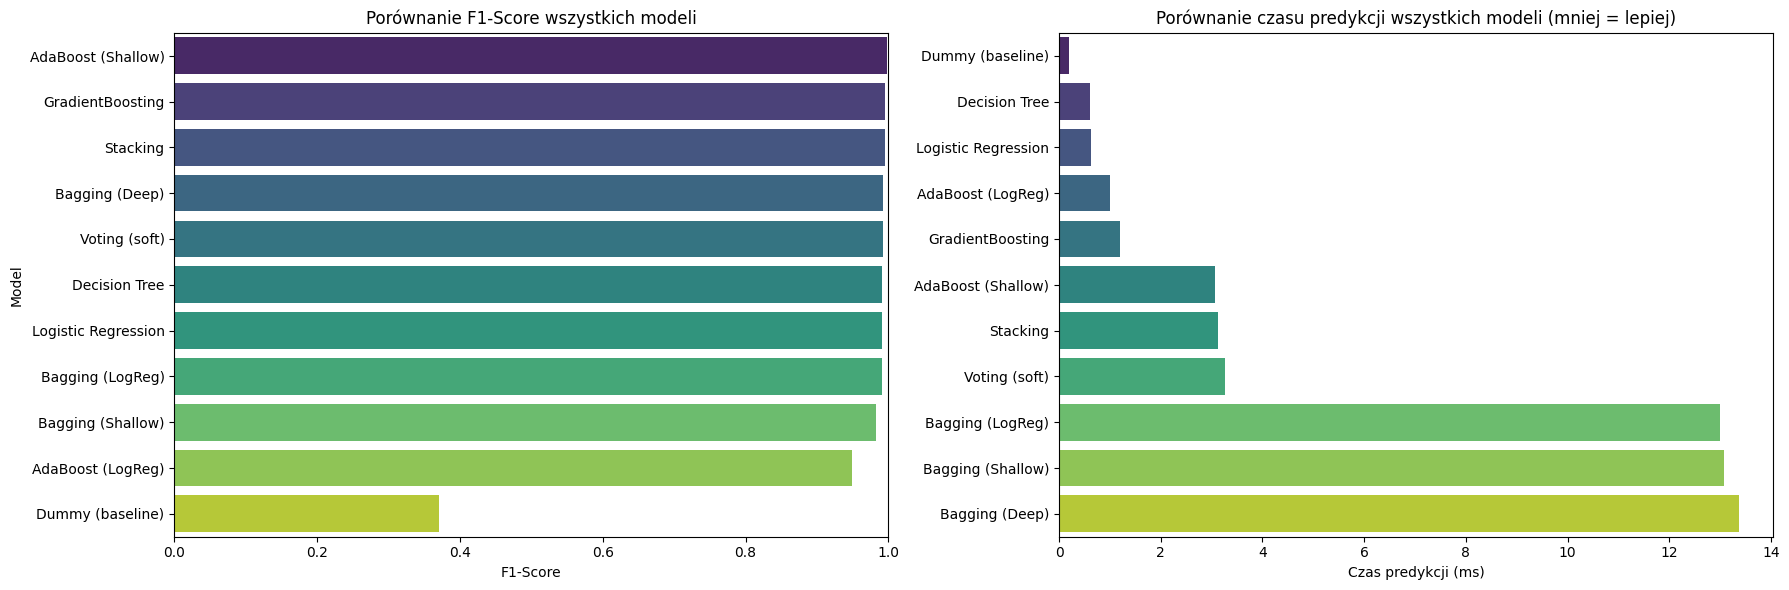

In [95]:
import matplotlib.pyplot as plt
import seaborn as pd
import seaborn as sns
import pandas as pd
import time
from sklearn.metrics import f1_score

models_to_evaluate = {
    "Dummy (baseline)": (baseline_model, X_test),
    "Decision Tree": (tree_model, X_test),
    "Logistic Regression": (logreg_model, X_test),
    "Bagging (Shallow)": (model_bag_shallow, X_test),
    "Bagging (Deep)": (model_bag_deep, X_test),
    "Bagging (LogReg)": (model_bag_logreg, X_test),
    "AdaBoost (Shallow)": (ada_shallow, X_test),
    "AdaBoost (LogReg)": (ada_logreg, X_test_scaled), # Ten model używał skalowanych danych testowych
    "GradientBoosting": (gb_model, X_test),
    "Voting (soft)": (voting_clf, X_test),
    "Stacking": (stacking_clf, X_test)
}

results = []
for name, (model, test_data) in models_to_evaluate.items():
    start_time = time.time()
    y_pred = model.predict(test_data)
    pred_time = time.time() - start_time
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({"Model": name, "F1-Score": f1, "Prediction Time (ms)": pred_time * 1000})

results_df = pd.DataFrame(results)

display(results_df.sort_values(by="F1-Score", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(
    data=results_df.sort_values(by="F1-Score", ascending=False), 
    x="F1-Score", 
    y="Model", 
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Porównanie F1-Score wszystkich modeli")
axes[0].set_xlim(0, 1.0)
axes[0].set_xlabel("F1-Score")
axes[0].set_ylabel("Model")

sns.barplot(
    data=results_df.sort_values(by="Prediction Time (ms)", ascending=True), 
    x="Prediction Time (ms)", 
    y="Model", 
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Porównanie czasu predykcji wszystkich modeli (mniej = lepiej)")
axes[1].set_xlabel("Czas predykcji (ms)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

## 1. EDA

In [96]:
# Nazwy kolumn zaczerpnięte z dokumentacji UCI (informacje o atrybutach)
# Zmienna celowa to 'class' (e = edible/jadalny, p = poisonous/trujący)
col_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Zmiana: podajemy nazwy kolumn bez obcinania pierwszego wiersza (ponieważ jest to wiersz z danymi, nie header)
file_path = "mushroom/agaricus-lepiota.data"
df_mush = pd.read_csv(file_path, header=None, names=col_names)

print("Kształt zbioru danych:", df_mush.shape)
display(df_mush.head())

Kształt zbioru danych: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [97]:

missing_roots = (df_mush['stalk-root'] == '?').sum()
print(f"Ilość brakujących danych (?) w uczeniu (stalk-root): {missing_roots} (z {len(df_mush)} wierszy)")

df_mush.replace('?', np.nan, inplace=True)

duplicates = df_mush.duplicated().sum()
print(f"Liczba wierszy będących całkowitymi duplikatami: {duplicates}")

df_mush.describe(include='all')

Ilość brakujących danych (?) w uczeniu (stalk-root): 2480 (z 8124 wierszy)
Liczba wierszy będących całkowitymi duplikatami: 0


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


zauwazamy ze veil-type ma wszystkie wartosci jako p wiec jest zbedny

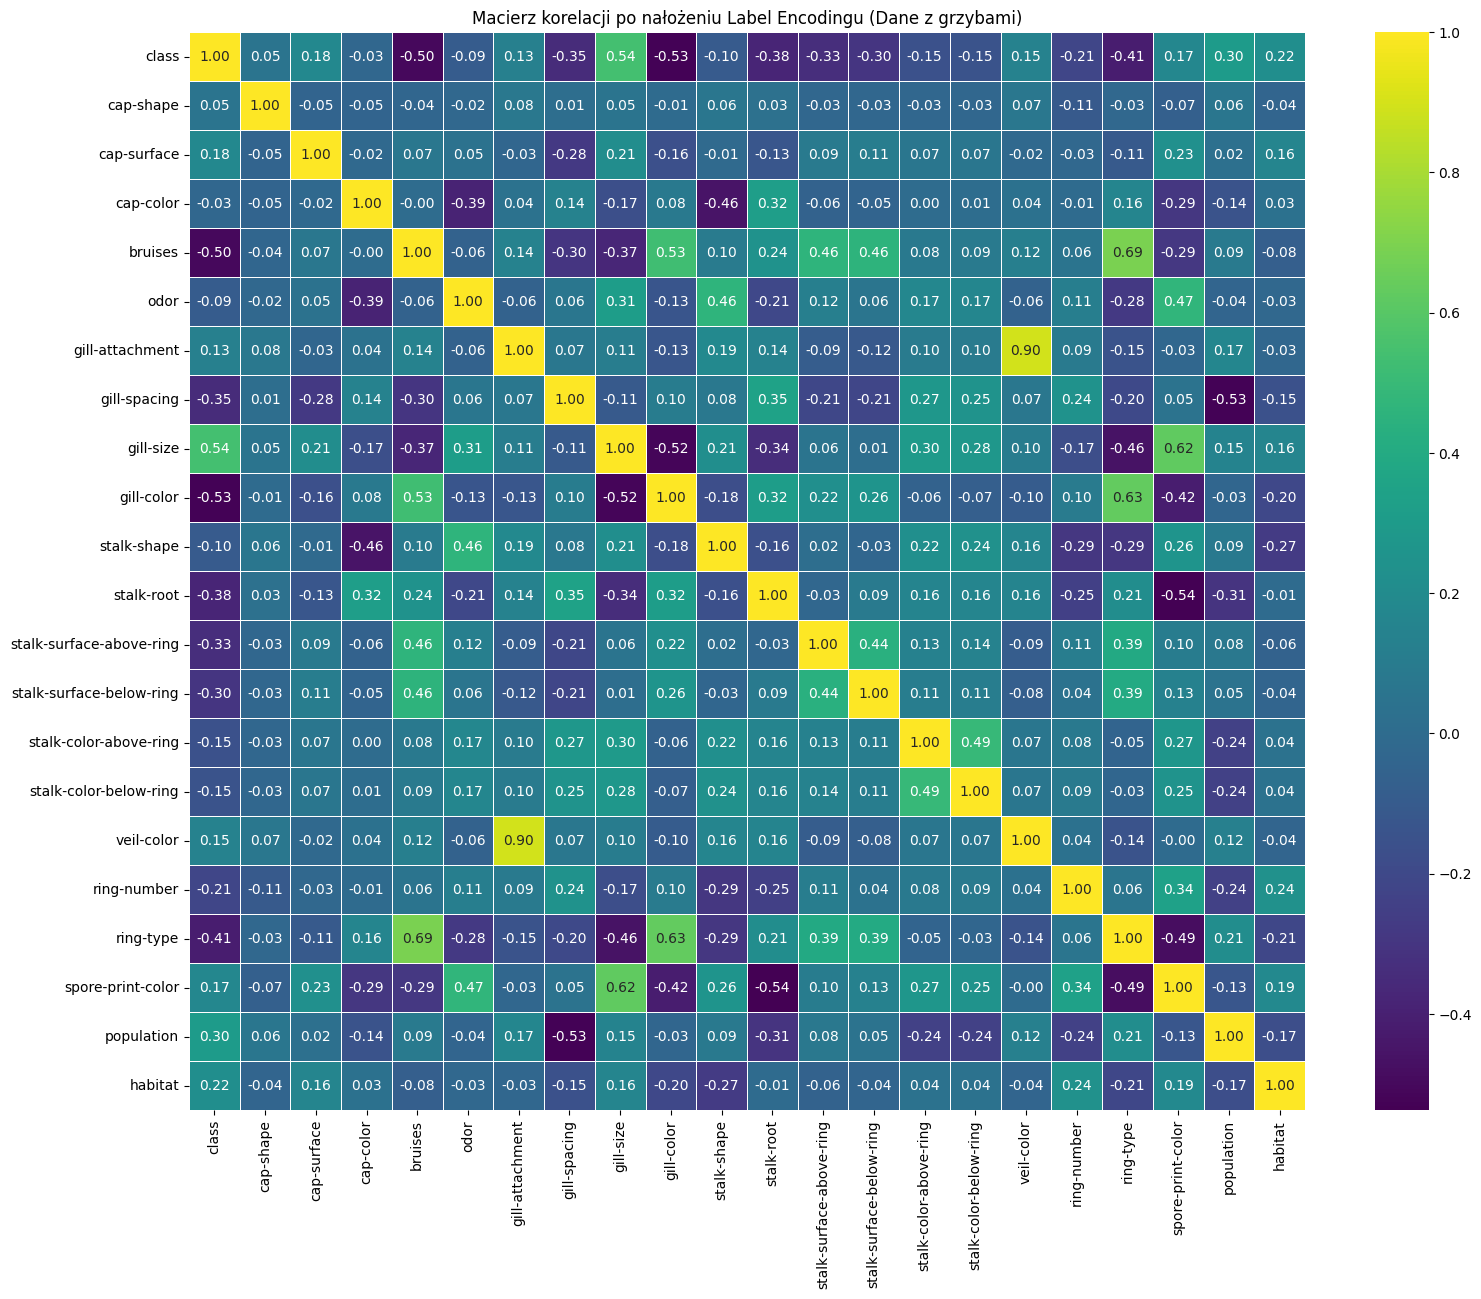

In [102]:
df_mush_encoded = df_mush.copy()

if 'veil-type' in df_mush_encoded.columns:
    df_mush_encoded = df_mush_encoded.drop(columns=['veil-type'])

for col in df_mush_encoded.columns:
    df_mush_encoded[col] = df_mush_encoded[col].astype('category').cat.codes

plt.figure(figsize=(18, 14))
corr_mush = df_mush_encoded.corr()
sns.heatmap(corr_mush, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji po nałożeniu Label Encodingu (Dane z grzybami)')
plt.show()

In [99]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_prep = df_mush.copy()

# class:  p -> 1, e -> 0
df_prep['class'] = df_prep['class'].map({'e': 0, 'p': 1})

# n -> 0 (none), o -> 1 (one), t -> 2 (two)
ring_mapping = {'n': 0, 'o': 1, 't': 2}
df_prep['ring-number'] = df_prep['ring-number'].map(ring_mapping)

# Kolumna 'veil-type' w całości zawiera to samo ['p'], usuwamy by nie psuła modeli
if 'veil-type' in df_prep.columns:
    df_prep = df_prep.drop(columns=['veil-type'])

# Zmienne binarne mapujemy na 0 i 1
binary_cols = [col for col in df_prep.columns if df_prep[col].nunique() == 2 and col != 'class']

print("--- Wykryte cechy binarne ---")
for col in binary_cols:
    unique_vals = df_prep[col].dropna().unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    df_prep[col] = df_prep[col].map(mapping)
    print(f"[{col}]: {unique_vals[0]} -> 0, {unique_vals[1]} -> 1")

# Pozostałe zmienne wielokategoryjne -> Label Encoding
# Algorytmy oparte na drzewach świetnie sobie poradzą z formatem Label Encodingu!

print("\n--- Nakładanie Label Encodingu ---")
# Pamiętamy o sprawdzaniu także typu 'string' w nowszych wersjach pandas
other_cols = [col for col in df_prep.select_dtypes(include=['object', 'string', 'category']).columns if col != 'class']
le = LabelEncoder()

for col in other_cols:
    # Uzupełniamy nan na wartość 'missing', co traktowane jest jako kolejna kategoria (dla 'stalk-root')
    df_prep[col] = df_prep[col].fillna('missing')
    df_prep[col] = le.fit_transform(df_prep[col])

print("\nKształt gotowego zbioru:", df_prep.shape)
display(df_prep.head())

# Podział na zbiór treningowy i testowy
print("\n--- Podział na zbiór treningowy i testowy ---")
X_mush = df_prep.drop(columns=['class'])
y_mush = df_prep['class']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mush, y_mush, test_size=0.2, random_state=42
)

print(f"X_train_m: {X_train_m.shape}, y_train_m: {y_train_m.shape}")
print(f"X_test_m: {X_test_m.shape}, y_test_m: {y_test_m.shape}")

--- Wykryte cechy binarne ---
[bruises]: t -> 0, f -> 1
[gill-attachment]: f -> 0, a -> 1
[gill-spacing]: c -> 0, w -> 1
[gill-size]: n -> 0, b -> 1
[stalk-shape]: e -> 0, t -> 1

--- Nakładanie Label Encodingu ---

Kształt gotowego zbioru: (8124, 22)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,0,6,0,0,0,4,...,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,0,0,0,0,1,4,...,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,0,3,0,0,1,5,...,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,0,6,0,0,0,5,...,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,1,5,0,1,1,4,...,2,2,7,7,2,1,0,3,0,1



--- Podział na zbiór treningowy i testowy ---
X_train_m: (6499, 21), y_train_m: (6499,)
X_test_m: (1625, 21), y_test_m: (1625,)


## 2. Modele

1. Decision Tree (Pojedyncze drzewo)
2. Random Forest (Ensemble)
3. AdaBoostClassifier (Ensemble z rodziny Boostingowych)

metryka: Interesuje nas najbardziej jak najwyższe **Recall** w kierunku wykrycia grzybów trujących ("Poisonous", przypisane jako `class = 1`). Każdą wątpliwość chcemy wyrzucać jako grzyb trujący (nawet za cenę niezebrania dobrych grzybów - False Positives z perspektywy jadalności, czyli predykcja 1 dla jadalnych). Zależy nam żeby minimalizować False Negatives (przepuszczenie pomyłką trującego).

Wyniki Treningu Modeli 


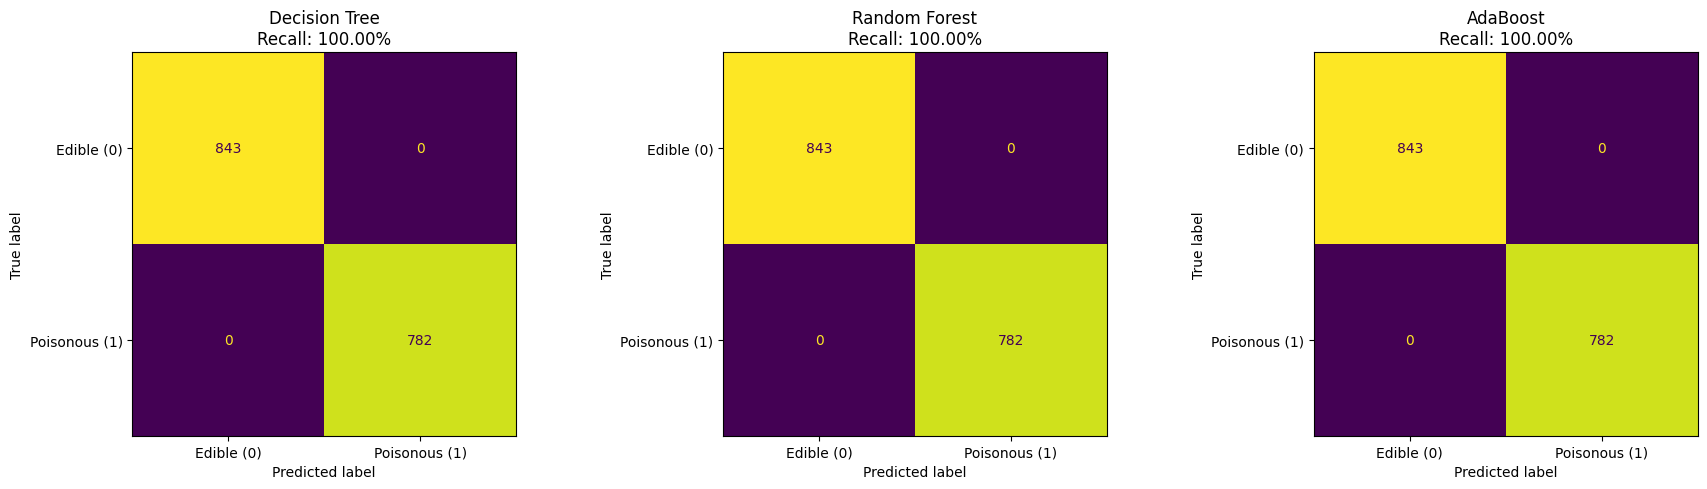

,Model,Recall (Trójące/P),Czas treningu [s]
0,Decision Tree,1.0,0.0066
1,Random Forest,1.0,0.1091
2,AdaBoost,1.0,0.1580


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import time

# Słownik modeli
models_mush = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=12),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', max_depth=8),
    "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=100)
}

results_mush = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

print("Wyniki Treningu Modeli ")

for idx, (name, model) in enumerate(models_mush.items()):
    start = time.time()
    model.fit(X_train_m, y_train_m)
    train_time = time.time() - start
    
    y_pred_m = model.predict(X_test_m)
    
    rec_m = recall_score(y_test_m, y_pred_m)
    
    results_mush.append({
        "Model": name,
        "Recall (Trójące/P)": rec_m,
        "Czas treningu [s]": round(train_time, 4)
    })
    
    cm = confusion_matrix(y_test_m, y_pred_m)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible (0)', 'Poisonous (1)'])
    disp.plot(cmap='viridis', ax=axes[idx], colorbar=False, values_format='d')
    axes[idx].set_title(f"{name}\nRecall: {rec_m*100:.2f}%")

plt.tight_layout()
plt.show()

df_results_mush = pd.DataFrame(results_mush).sort_values(by="Recall (Trójące/P)", ascending=False)
display(df_results_mush)

/var/folders/s5/fc27vd4n1v7_7snyvwrbdsn40000gn/T/ipykernel_88069/1298539998.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importances.head(10), x='Ważność (Feature Importance)', y='Atrybut', palette='viridis')


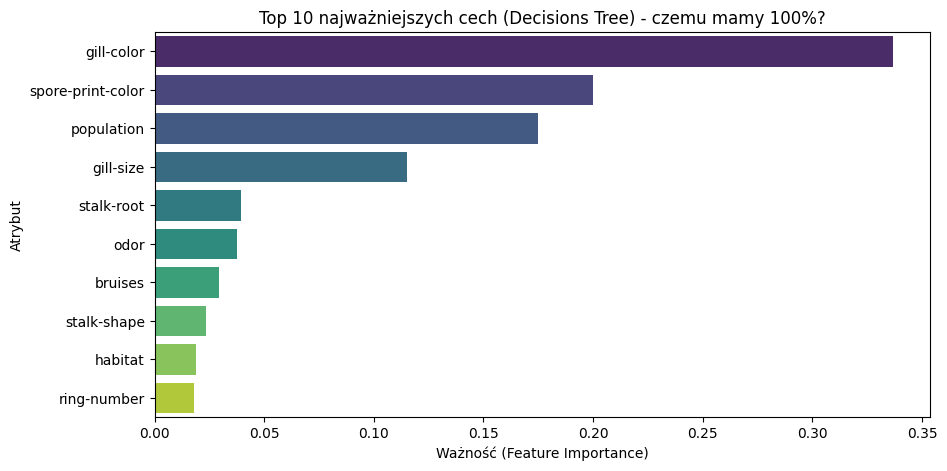

In [101]:
import seaborn as sns

importances = dt_model.feature_importances_

df_importances = pd.DataFrame({
    'Atrybut': X_train_m.columns,
    'Ważność (Feature Importance)': importances
}).sort_values(by='Ważność (Feature Importance)', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importances.head(10), x='Ważność (Feature Importance)', y='Atrybut', palette='viridis')
plt.title("Top 10 najważniejszych cech (Decisions Tree) - czemu mamy 100%?")
plt.show()

modele drzewne okazaly sie niesmaowicie skuteczne w tym zadaniu wlasnie przez to, ze mielismy dane nominalne w wiekszosci oraz atrybut gill-color ktory mial gigantyczne znaczenie dla wyniku class